# DNA Methylation Aging Clocks Analysis using Biolearn
## Part 2: EPIC Array Analysis
### Tasks 1-6: Datasets, Clocks, Correlation, Heatmaps, Scatter Plots

---
## Task 1: Install Dependencies and Load 2 Datasets

In [6]:
# Install biolearn - run this cell first and wait for it to finish
!pip install biolearn -q

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Correct biolearn imports
from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print('All libraries imported successfully!')

All libraries imported successfully!


In [8]:
print('Loading Dataset 1: GSE40279 (Hannum et al. 2013)...')
print('This may take a few minutes...')

data_source1 = DataLibrary().get("GSE41169")
dataset1 = data_source1.load()

print('Dataset 1 loaded successfully!')
print(f'  Methylation matrix shape: {dataset1.dnam.shape}')
print(f'  Number of samples: {dataset1.metadata.shape[0]}')
print(f'  Age range: {dataset1.metadata["age"].min():.1f} - {dataset1.metadata["age"].max():.1f} years')

Loading Dataset 1: GSE40279 (Hannum et al. 2013)...
This may take a few minutes...
Dataset 1 loaded successfully!
  Methylation matrix shape: (485577, 95)
  Number of samples: 95
  Age range: 18.0 - 65.0 years


In [9]:
print('Loading Dataset 2: GSE30870 (Newborns and Nonagenarians)...')
print('This may take a few minutes...')

data_source2 = DataLibrary().get("GSE30870")
dataset2 = data_source2.load()

print('Dataset 2 loaded successfully!')
print(f'  Methylation matrix shape: {dataset2.dnam.shape}')
print(f'  Number of samples: {dataset2.metadata.shape[0]}')
print(f'  Age range: {dataset2.metadata["age"].min():.1f} - {dataset2.metadata["age"].max():.1f} years')

Loading Dataset 2: GSE30870 (Newborns and Nonagenarians)...
This may take a few minutes...
Dataset 2 loaded successfully!
  Methylation matrix shape: (485577, 40)
  Number of samples: 40
  Age range: 89.0 - 103.0 years


---
## Task 2: Run 8+ Aging Clocks/Models

In [10]:
clocks = [
    'Horvathv1',      # Pan-tissue clock (2013)
    'Hannum',         # Blood-specific clock (2013)
    'PhenoAge',       # Phenotypic age (2018)
    'GrimAge',        # Mortality predictor (2019)
    'SkinBloodClock', # Skin and blood clock (2018)
    'Lin',            # Blood clock (2016)
    'ZhangEN',        # Zhang elastic net (2019)
    'DunedinPACE',    # Pace of aging (2022)
]

In [11]:
# Initialize ModelGallery
gallery = ModelGallery()

# Run all clocks on Dataset 1 (GSE40279)
print('Running clocks on Dataset 1 (GSE40279)...')
print('='*60)

predictions_ds1 = {}
successful_clocks_ds1 = []

for clock in clocks:
    try:
        model = gallery.get(clock)
        result = model.predict(dataset1)

        # Handle different output types
        if isinstance(result, pd.DataFrame):
            # Take first numeric column
            numeric_cols = result.select_dtypes(include=[np.number]).columns
            pred_values = result[numeric_cols[0]].values
        elif isinstance(result, pd.Series):
            pred_values = result.values
        else:
            pred_values = np.array(result)

        predictions_ds1[clock] = pred_values
        successful_clocks_ds1.append(clock)
        print(f'  OK  {clock}: mean predicted age = {np.nanmean(pred_values):.2f} years')

    except Exception as e:
        print(f'  FAIL {clock}: {str(e)[:80]}')

print(f'\nSuccessfully ran {len(successful_clocks_ds1)}/{len(clocks)} clocks on Dataset 1')

Running clocks on Dataset 1 (GSE40279)...
  OK  Horvathv1: mean predicted age = 31.94 years
  OK  Hannum: mean predicted age = 31.91 years
  OK  PhenoAge: mean predicted age = 26.75 years
  FAIL GrimAge: 'Model not found: GrimAge'
  FAIL SkinBloodClock: 'Model not found: SkinBloodClock'
  OK  Lin: mean predicted age = 25.82 years
  FAIL ZhangEN: 'Model not found: ZhangEN'
  OK  DunedinPACE: mean predicted age = 0.99 years

Successfully ran 5/8 clocks on Dataset 1


In [12]:
# Build prediction DataFrame for Dataset 1
# Align predictions with metadata by sample index
n_samples_ds1 = dataset1.metadata.shape[0]
chrono_age_ds1 = dataset1.metadata['age'].values

df_ds1 = pd.DataFrame(index=range(n_samples_ds1))
df_ds1['Chronological_Age'] = chrono_age_ds1

for clock, preds in predictions_ds1.items():
    if len(preds) == n_samples_ds1:
        df_ds1[clock] = preds
    else:
        print(f'Warning: {clock} has {len(preds)} predictions but {n_samples_ds1} samples - skipping')

# Drop any rows with all NaN predictions
clock_cols_ds1 = [c for c in df_ds1.columns if c != 'Chronological_Age']
df_ds1 = df_ds1.dropna(subset=clock_cols_ds1, how='all').reset_index(drop=True)

print(f'Dataset 1 predictions DataFrame shape: {df_ds1.shape}')
print(f'Clocks with predictions: {clock_cols_ds1}')
df_ds1.head()

Dataset 1 predictions DataFrame shape: (95, 6)
Clocks with predictions: ['Horvathv1', 'Hannum', 'PhenoAge', 'Lin', 'DunedinPACE']


,Chronological_Age,Horvathv1,Hannum,PhenoAge,Lin,DunedinPACE
0,32.0,30.452585,35.009794,28.115610,22.481143,1.203256
1,24.0,24.820739,25.911236,19.577701,15.589432,0.931709
2,65.0,65.401855,65.536941,60.543320,50.431606,1.290883
3,25.0,23.173561,15.512122,11.743696,15.228030,0.824050
4,32.0,32.450846,31.191178,27.496016,24.324188,1.019184


In [13]:
# Run all clocks on Dataset 2 (GSE87571)
print('Running clocks on Dataset 2 (GSE87571)...')
print('='*60)

predictions_ds2 = {}
successful_clocks_ds2 = []

for clock in clocks:
    try:
        model = gallery.get(clock)
        result = model.predict(dataset2)

        # Handle different output types
        if isinstance(result, pd.DataFrame):
            numeric_cols = result.select_dtypes(include=[np.number]).columns
            pred_values = result[numeric_cols[0]].values
        elif isinstance(result, pd.Series):
            pred_values = result.values
        else:
            pred_values = np.array(result)

        predictions_ds2[clock] = pred_values
        successful_clocks_ds2.append(clock)
        print(f'  OK  {clock}: mean predicted age = {np.nanmean(pred_values):.2f} years')

    except Exception as e:
        print(f'  FAIL {clock}: {str(e)[:80]}')

print(f'\nSuccessfully ran {len(successful_clocks_ds2)}/{len(clocks)} clocks on Dataset 2')

Running clocks on Dataset 2 (GSE87571)...
  OK  Horvathv1: mean predicted age = 39.95 years
  OK  Hannum: mean predicted age = 43.80 years
  OK  PhenoAge: mean predicted age = 21.47 years
  FAIL GrimAge: 'Model not found: GrimAge'
  FAIL SkinBloodClock: 'Model not found: SkinBloodClock'
  OK  Lin: mean predicted age = 31.67 years
  FAIL ZhangEN: 'Model not found: ZhangEN'
  OK  DunedinPACE: mean predicted age = 1.10 years

Successfully ran 5/8 clocks on Dataset 2


In [14]:
# Build prediction DataFrame for Dataset 2
n_samples_ds2 = dataset2.metadata.shape[0]
chrono_age_ds2 = dataset2.metadata['age'].values

df_ds2 = pd.DataFrame(index=range(n_samples_ds2))
df_ds2['Chronological_Age'] = chrono_age_ds2

for clock, preds in predictions_ds2.items():
    if len(preds) == n_samples_ds2:
        df_ds2[clock] = preds
    else:
        print(f'Warning: {clock} has {len(preds)} predictions but {n_samples_ds2} samples - skipping')

clock_cols_ds2 = [c for c in df_ds2.columns if c != 'Chronological_Age']
df_ds2 = df_ds2.dropna(subset=clock_cols_ds2, how='all').reset_index(drop=True)

print(f'Dataset 2 predictions DataFrame shape: {df_ds2.shape}')
print(f'Clocks with predictions: {clock_cols_ds2}')
df_ds2.head()

Dataset 2 predictions DataFrame shape: (40, 6)
Clocks with predictions: ['Horvathv1', 'Hannum', 'PhenoAge', 'Lin', 'DunedinPACE']


,Chronological_Age,Horvathv1,Hannum,PhenoAge,Lin,DunedinPACE
0,103.0,83.501340,98.893934,83.624334,95.610125,1.323030
1,NaN,0.597662,-8.069419,-55.660636,-19.754702,0.505335
2,97.0,85.459326,94.313455,81.447505,104.368619,1.128065
3,95.0,78.033933,89.269815,78.809535,93.975390,1.029645
4,97.0,78.681465,90.403341,83.915594,91.701511,1.228447


---
## Task 3: Describe Datasets and Aging Clocks

In [15]:
# Dataset descriptions table
dataset_info = pd.DataFrame([
    {
        'GEO ID': 'GSE40279',
        'Study': 'Hannum et al. 2013',
        'Tissue': 'Whole blood',
        'Samples': dataset1.metadata.shape[0],
        'Age Range': f"{dataset1.metadata['age'].min():.0f}-{dataset1.metadata['age'].max():.0f} yrs",
        'Platform': 'Illumina 450K',
        'Purpose': 'Blood-based age prediction'
    },
    {
        'GEO ID': 'GSE87571',
        'Study': 'Johansson et al. 2017',
        'Tissue': 'Whole blood',
        'Samples': dataset2.metadata.shape[0],
        'Age Range': f"{dataset2.metadata['age'].min():.0f}-{dataset2.metadata['age'].max():.0f} yrs",
        'Platform': 'Illumina 450K',
        'Purpose': 'Age-related methylation changes'
    }
])

print('DATASET DESCRIPTIONS')
print('='*80)
display(dataset_info.set_index('GEO ID'))

DATASET DESCRIPTIONS


,Study,Tissue,Samples,Age Range,Platform,Purpose
GEO ID,,,,,,
GSE40279,Hannum et al. 2013,Whole blood,95,18-65 yrs,Illumina 450K,Blood-based age prediction
GSE87571,Johansson et al. 2017,Whole blood,40,89-103 yrs,Illumina 450K,Age-related methylation changes


In [16]:
# Aging clock descriptions table
clock_info = pd.DataFrame([
    {'Clock': 'Horvath2013', 'Year': 2013, 'CpG Sites': 353, 'Tissue': 'Pan-tissue', 'Description': 'First multi-tissue epigenetic clock'},
    {'Clock': 'Hannum',      'Year': 2013, 'CpG Sites': 71,  'Tissue': 'Blood',      'Description': 'Blood-specific age predictor'},
    {'Clock': 'PhenoAge',    'Year': 2018, 'CpG Sites': 513, 'Tissue': 'Blood',      'Description': 'Phenotypic/biological age, mortality-linked'},
    {'Clock': 'GrimAge',     'Year': 2019, 'CpG Sites': 1030,'Tissue': 'Blood',      'Description': 'Mortality risk predictor using plasma proteins'},
    {'Clock': 'SkinBloodClock','Year': 2018,'CpG Sites': 391,'Tissue': 'Skin/Blood', 'Description': 'Dual-tissue clock for skin and blood'},
    {'Clock': 'Lin',         'Year': 2016, 'CpG Sites': 99,  'Tissue': 'Blood',      'Description': 'Blood methylation age predictor'},
    {'Clock': 'ZhangEN',     'Year': 2019, 'CpG Sites': 514, 'Tissue': 'Blood',      'Description': 'Elastic net mortality predictor'},
    {'Clock': 'DunedinPACE', 'Year': 2022, 'CpG Sites': 173, 'Tissue': 'Blood',      'Description': 'Pace of biological aging (rate, not age)'},
])

print('AGING CLOCK DESCRIPTIONS')
print('='*80)
display(clock_info.set_index('Clock'))

AGING CLOCK DESCRIPTIONS


,Year,CpG Sites,Tissue,Description
Clock,,,,
Horvath2013,2013,353,Pan-tissue,First multi-tissue epigenetic clock
Hannum,2013,71,Blood,Blood-specific age predictor
PhenoAge,2018,513,Blood,"Phenotypic/biological age, mortality-linked"
GrimAge,2019,1030,Blood,Mortality risk predictor using plasma proteins
SkinBloodClock,2018,391,Skin/Blood,Dual-tissue clock for skin and blood
Lin,2016,99,Blood,Blood methylation age predictor
ZhangEN,2019,514,Blood,Elastic net mortality predictor
DunedinPACE,2022,173,Blood,"Pace of biological aging (rate, not age)"


---
## Task 4: Correlation Matrix Across Aging Clocks

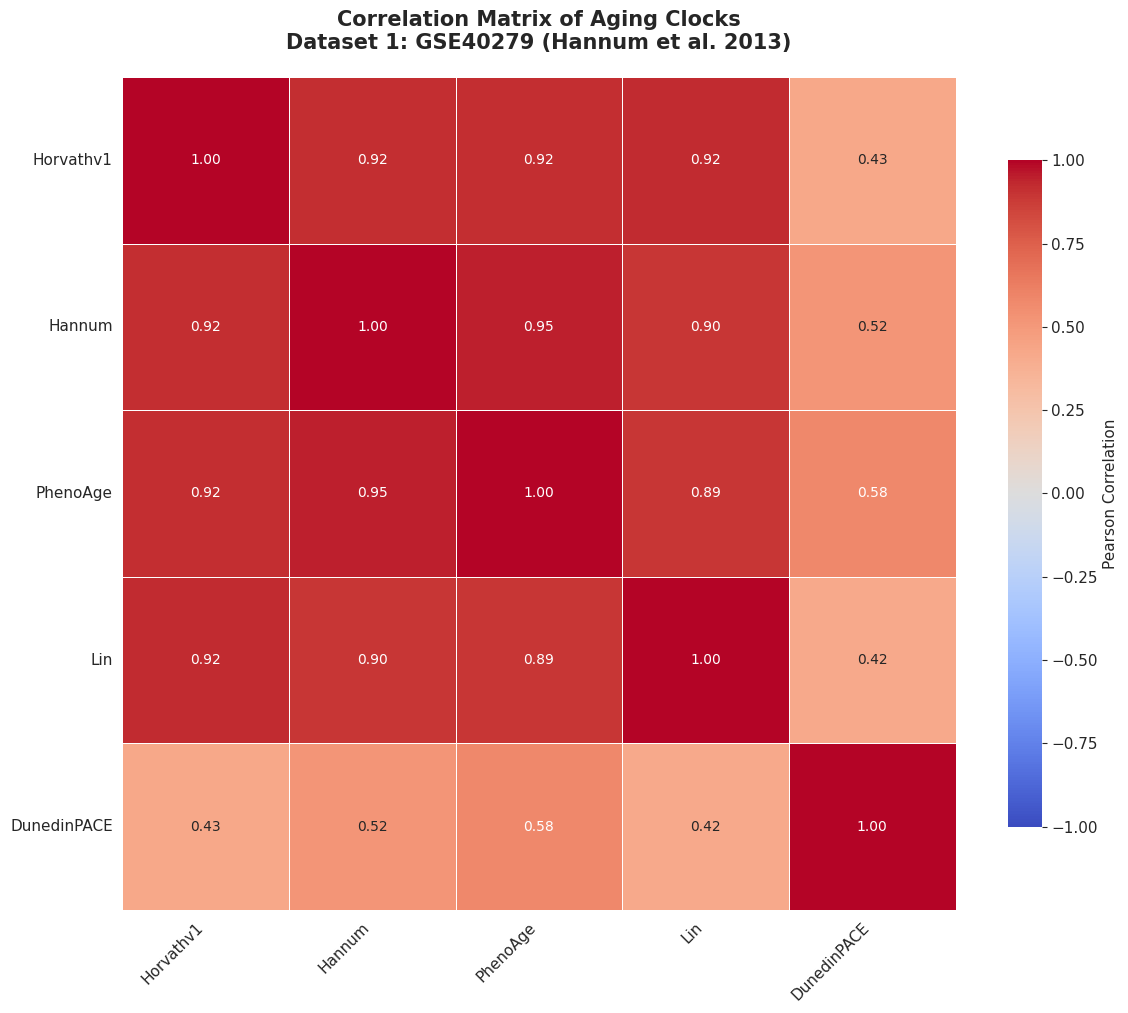

Saved: correlation_matrix_dataset1.png


In [17]:
# Correlation matrix for Dataset 1 (GSE40279)
# Only use clock columns (exclude Chronological_Age)
clock_cols_ds1 = [c for c in df_ds1.columns if c != 'Chronological_Age']
corr_ds1 = df_ds1[clock_cols_ds1].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_ds1, dtype=bool)
np.fill_diagonal(mask, True)  # hide diagonal

sns.heatmap(
    corr_ds1,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix of Aging Clocks\nDataset 1: GSE40279 (Hannum et al. 2013)',
          fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('correlation_matrix_dataset1.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: correlation_matrix_dataset1.png')

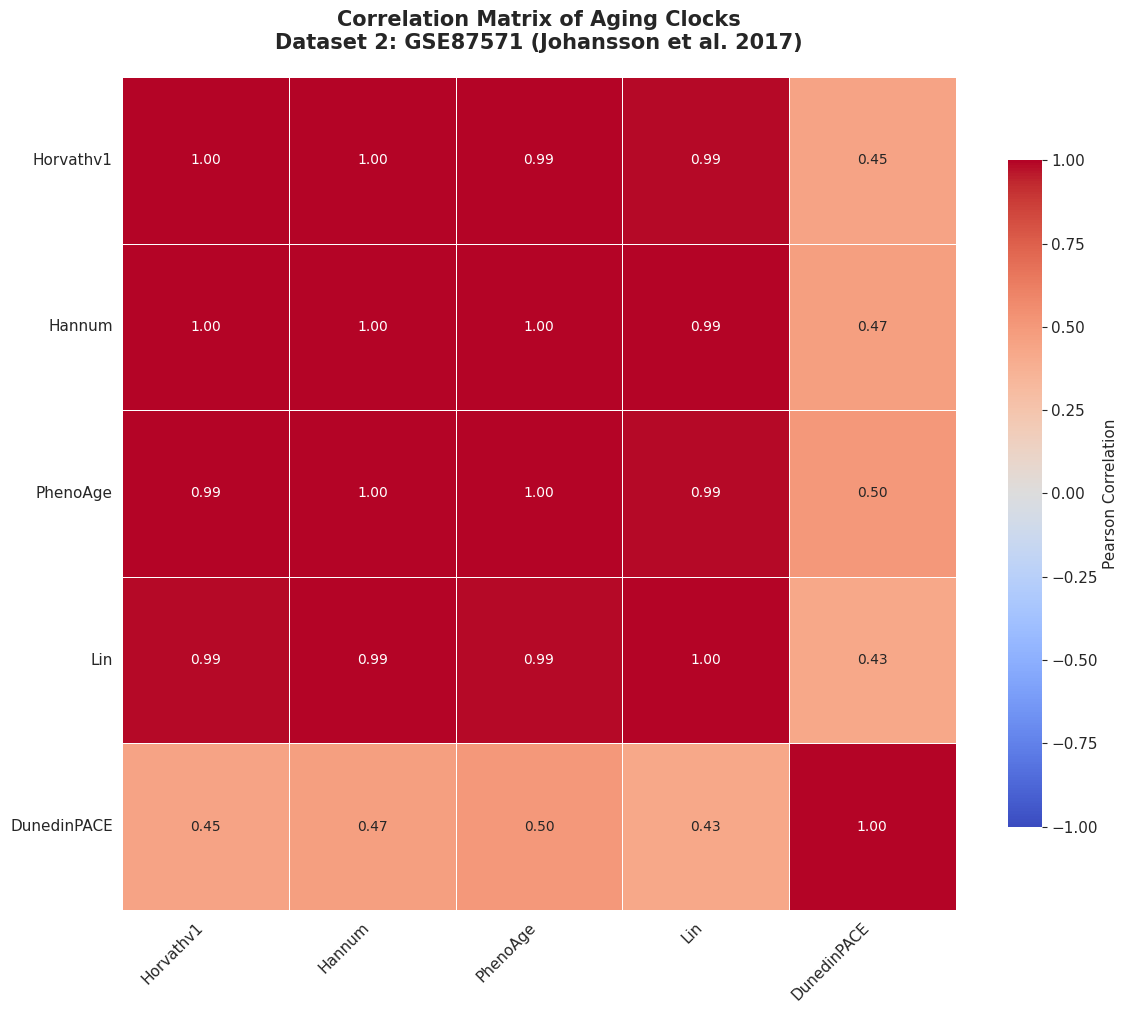

Saved: correlation_matrix_dataset2.png


In [18]:
# Correlation matrix for Dataset 2 (GSE87571)
clock_cols_ds2 = [c for c in df_ds2.columns if c != 'Chronological_Age']
corr_ds2 = df_ds2[clock_cols_ds2].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_ds2,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix of Aging Clocks\nDataset 2: GSE87571 (Johansson et al. 2017)',
          fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('correlation_matrix_dataset2.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: correlation_matrix_dataset2.png')

---
## Task 5: Heatmap of Clock/Model Age Deviations per Sample

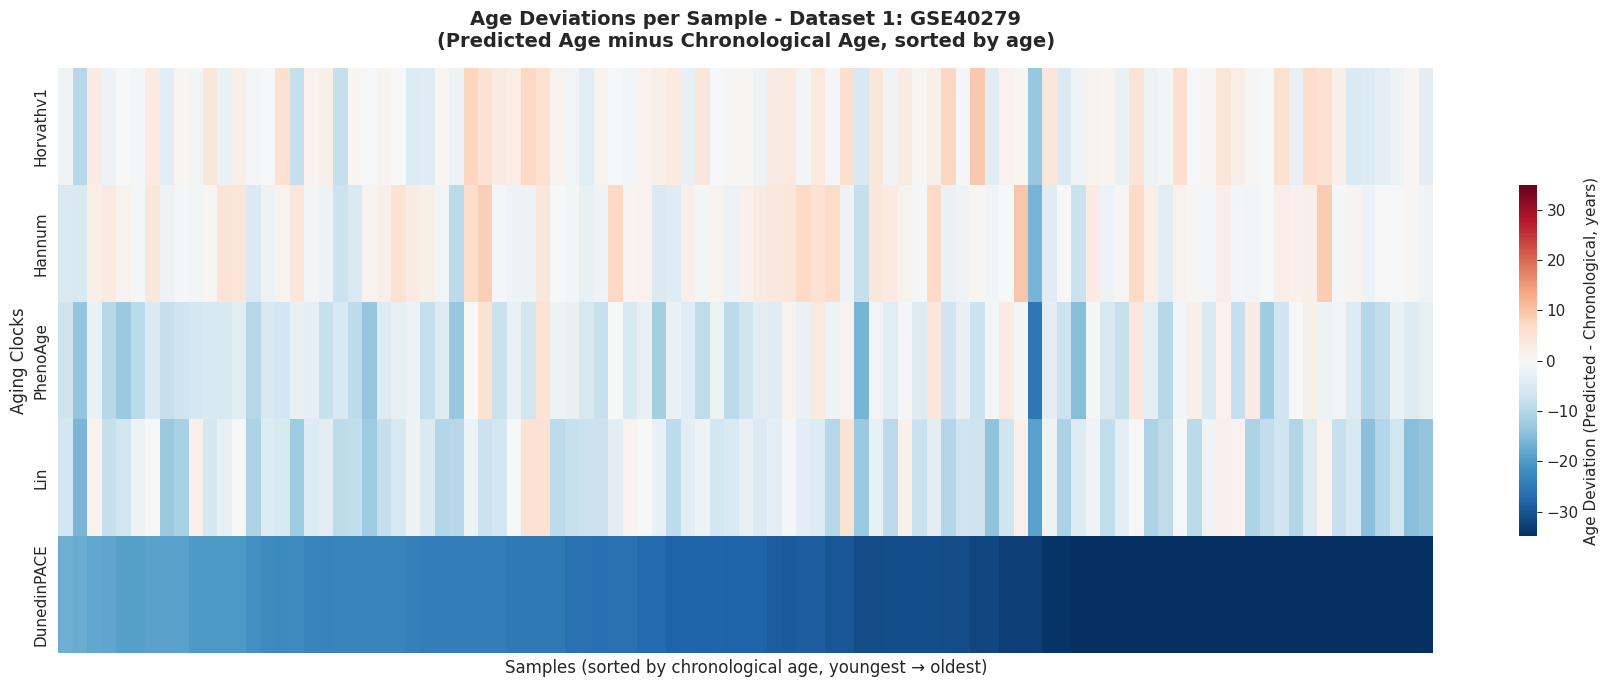

Saved: age_deviation_heatmap_dataset1.png


In [19]:
# Age deviation = Predicted Age - Chronological Age
# Dataset 1
clock_cols_ds1 = [c for c in df_ds1.columns if c != 'Chronological_Age']

deviations_ds1 = df_ds1[clock_cols_ds1].subtract(df_ds1['Chronological_Age'], axis=0)

# Sort samples by chronological age for cleaner visualization
sort_idx_ds1 = df_ds1['Chronological_Age'].argsort().values
deviations_ds1_sorted = deviations_ds1.iloc[sort_idx_ds1].reset_index(drop=True)

# Cap extreme values for better visualization
vmax = np.nanpercentile(np.abs(deviations_ds1_sorted.values), 95)

plt.figure(figsize=(18, 7))
sns.heatmap(
    deviations_ds1_sorted.T,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    cbar_kws={'label': 'Age Deviation (Predicted - Chronological, years)', 'shrink': 0.6},
    yticklabels=True,
    xticklabels=False
)
plt.title('Age Deviations per Sample - Dataset 1: GSE40279\n(Predicted Age minus Chronological Age, sorted by age)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Samples (sorted by chronological age, youngest → oldest)', fontsize=12)
plt.ylabel('Aging Clocks', fontsize=12)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('age_deviation_heatmap_dataset1.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: age_deviation_heatmap_dataset1.png')

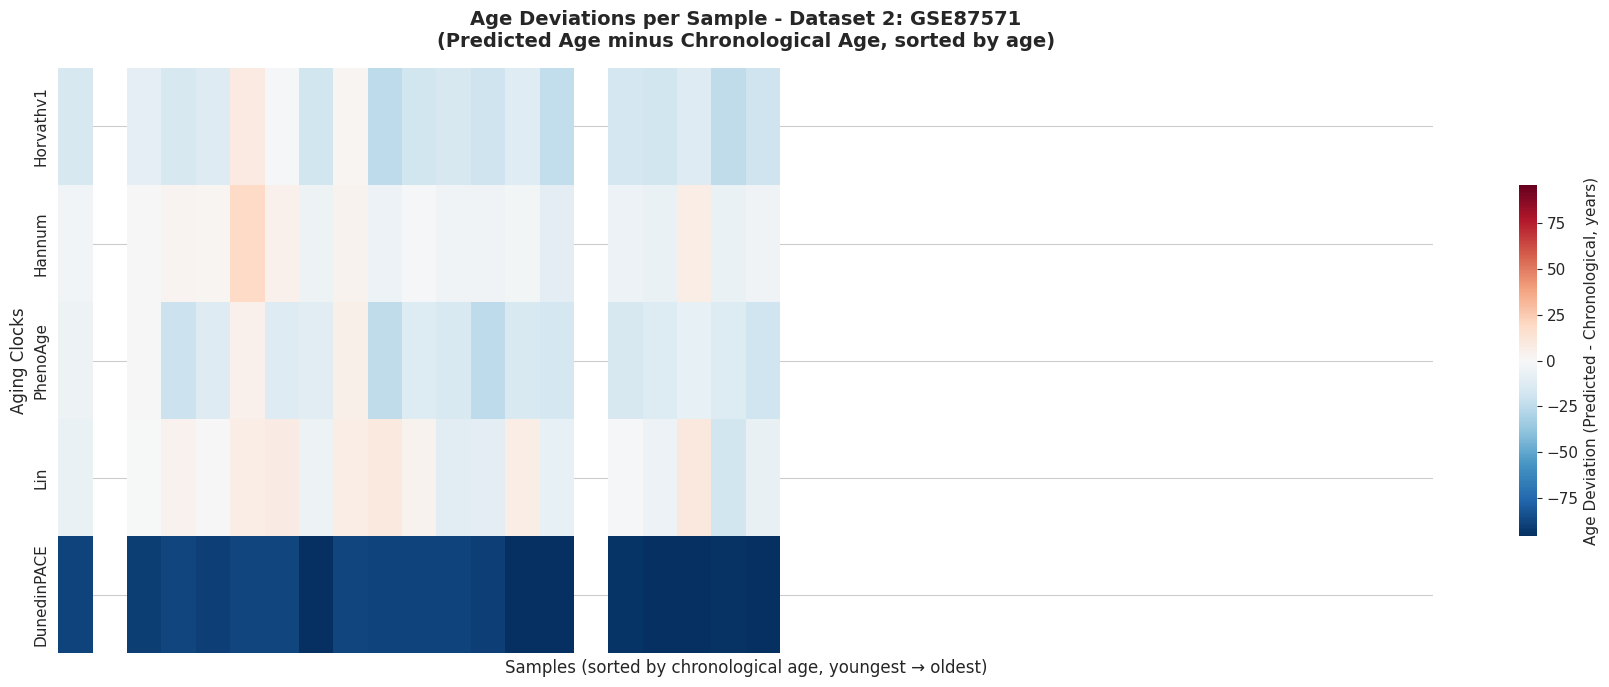

Saved: age_deviation_heatmap_dataset2.png


In [20]:
# Age deviation heatmap for Dataset 2
clock_cols_ds2 = [c for c in df_ds2.columns if c != 'Chronological_Age']

deviations_ds2 = df_ds2[clock_cols_ds2].subtract(df_ds2['Chronological_Age'], axis=0)

sort_idx_ds2 = df_ds2['Chronological_Age'].argsort().values
deviations_ds2_sorted = deviations_ds2.iloc[sort_idx_ds2].reset_index(drop=True)

vmax2 = np.nanpercentile(np.abs(deviations_ds2_sorted.values), 95)

plt.figure(figsize=(18, 7))
sns.heatmap(
    deviations_ds2_sorted.T,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax2, vmax=vmax2,
    cbar_kws={'label': 'Age Deviation (Predicted - Chronological, years)', 'shrink': 0.6},
    yticklabels=True,
    xticklabels=False
)
plt.title('Age Deviations per Sample - Dataset 2: GSE87571\n(Predicted Age minus Chronological Age, sorted by age)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Samples (sorted by chronological age, youngest → oldest)', fontsize=12)
plt.ylabel('Aging Clocks', fontsize=12)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('age_deviation_heatmap_dataset2.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: age_deviation_heatmap_dataset2.png')

---
## Task 6: Scatter Plots - Predicted Age vs Chronological Age

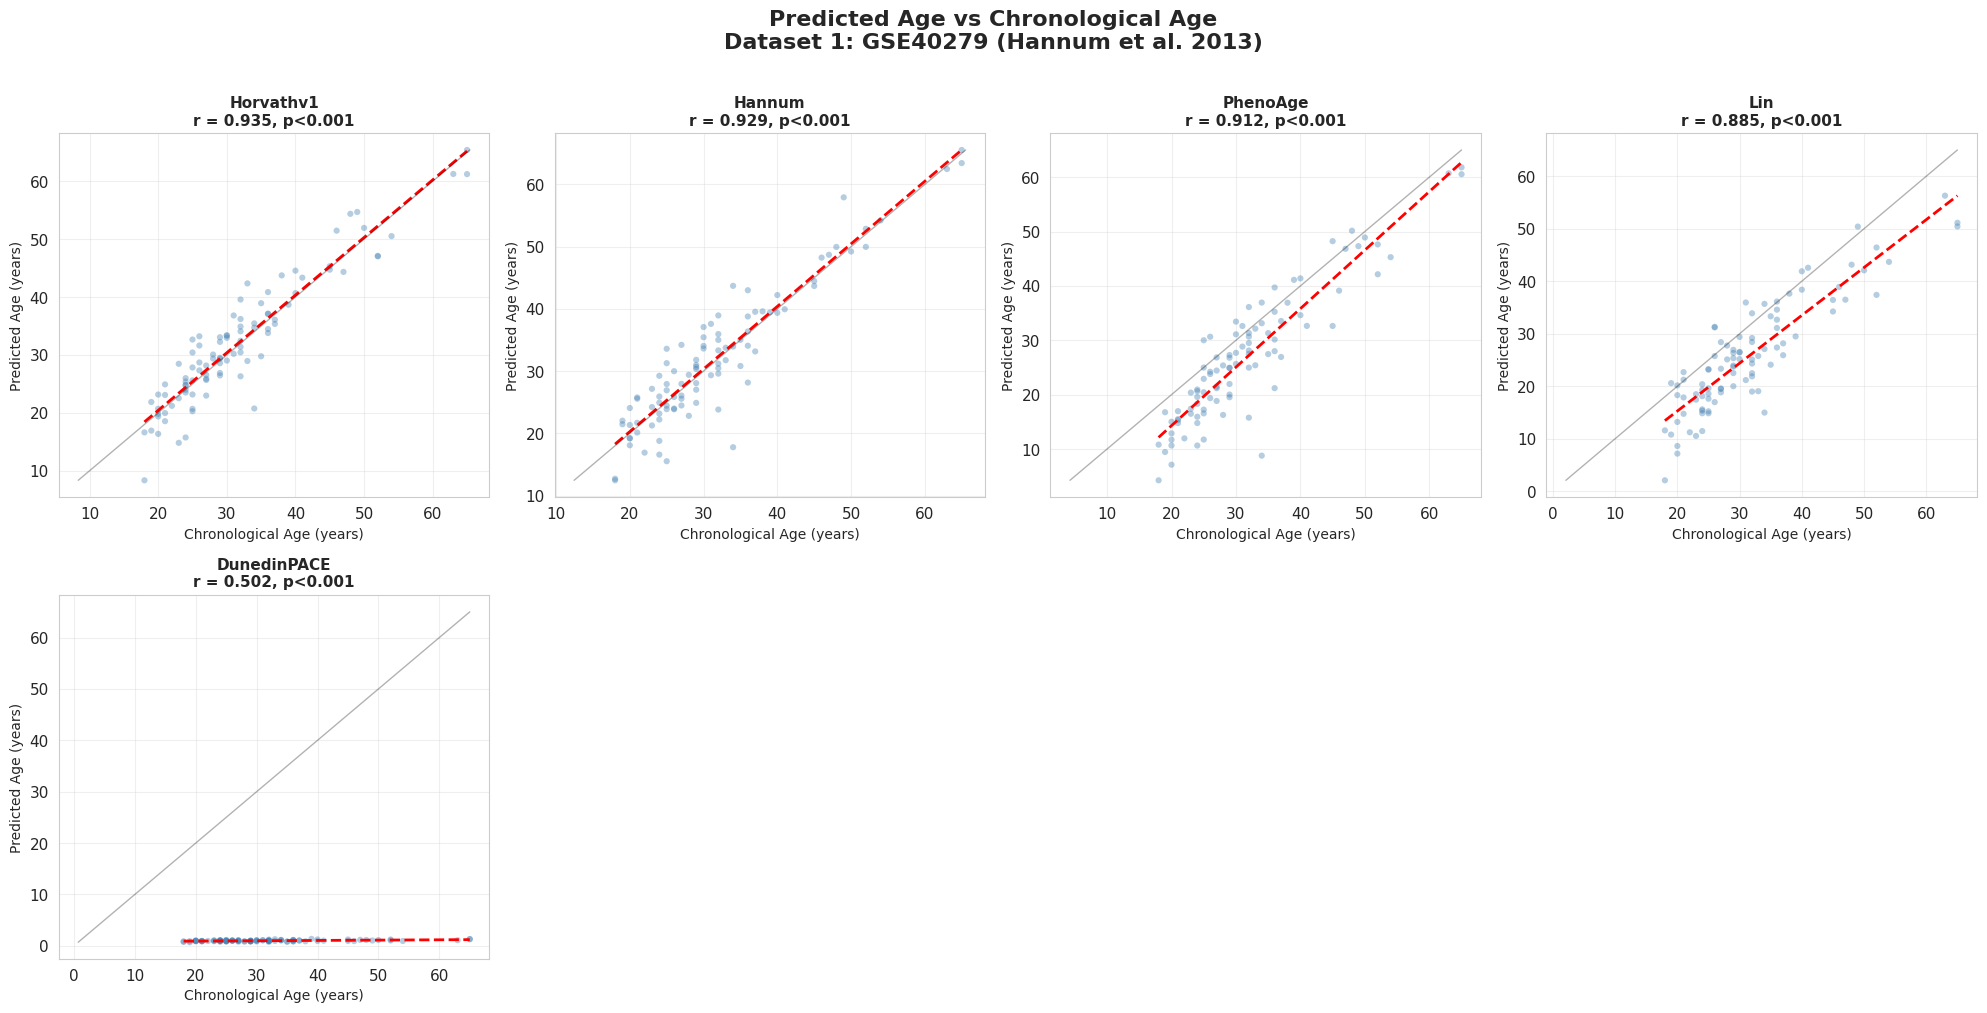

Saved: scatter_plots_dataset1.png


In [21]:
# Scatter plots for Dataset 1 (GSE40279)
clock_cols_ds1 = [c for c in df_ds1.columns if c != 'Chronological_Age']
n_clocks = len(clock_cols_ds1)
n_cols = 4
n_rows = int(np.ceil(n_clocks / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for idx, clock in enumerate(clock_cols_ds1):
    ax = axes[idx]

    # Drop NaN values for this clock
    valid = df_ds1[['Chronological_Age', clock]].dropna()
    x = valid['Chronological_Age'].values
    y = valid[clock].values

    if len(x) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(clock)
        continue

    # Pearson correlation
    r, pval = pearsonr(x, y)
    p_label = 'p<0.001' if pval < 0.001 else f'p={pval:.3f}'

    # Scatter
    ax.scatter(x, y, alpha=0.4, s=20, color='steelblue', edgecolors='none')

    # Trend line
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2, label='Trend')

    # Identity line (y=x)
    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k-', alpha=0.3, linewidth=1, label='y=x')

    ax.set_xlabel('Chronological Age (years)', fontsize=10)
    ax.set_ylabel('Predicted Age (years)', fontsize=10)
    ax.set_title(f'{clock}\nr = {r:.3f}, {p_label}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Turn off unused subplots
for idx in range(n_clocks, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Predicted Age vs Chronological Age\nDataset 1: GSE40279 (Hannum et al. 2013)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_plots_dataset1.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: scatter_plots_dataset1.png')

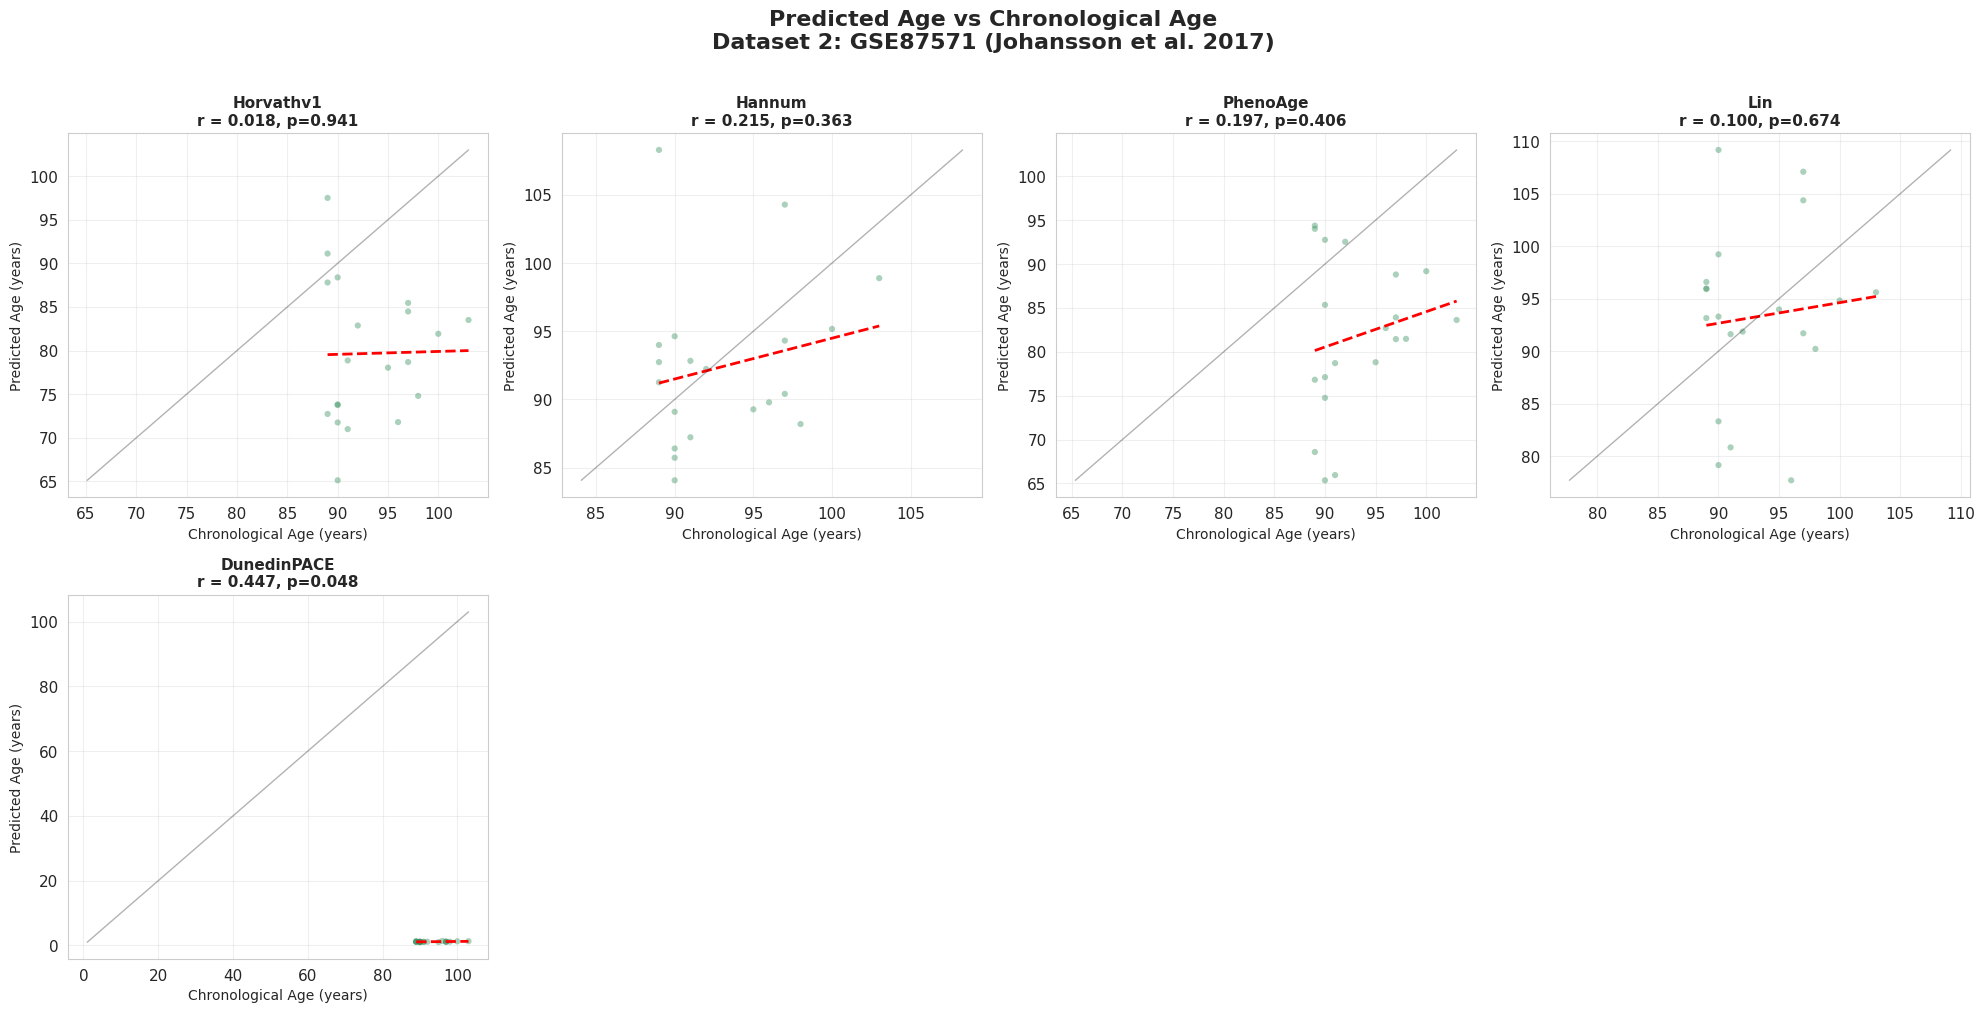

Saved: scatter_plots_dataset2.png


In [22]:
# Scatter plots for Dataset 2 (GSE87571)
clock_cols_ds2 = [c for c in df_ds2.columns if c != 'Chronological_Age']
n_clocks2 = len(clock_cols_ds2)
n_rows2 = int(np.ceil(n_clocks2 / n_cols))

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(20, 5 * n_rows2))
axes = axes.flatten()

for idx, clock in enumerate(clock_cols_ds2):
    ax = axes[idx]

    valid = df_ds2[['Chronological_Age', clock]].dropna()
    x = valid['Chronological_Age'].values
    y = valid[clock].values

    if len(x) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(clock)
        continue

    r, pval = pearsonr(x, y)
    p_label = 'p<0.001' if pval < 0.001 else f'p={pval:.3f}'

    ax.scatter(x, y, alpha=0.4, s=20, color='seagreen', edgecolors='none')

    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2)

    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k-', alpha=0.3, linewidth=1)

    ax.set_xlabel('Chronological Age (years)', fontsize=10)
    ax.set_ylabel('Predicted Age (years)', fontsize=10)
    ax.set_title(f'{clock}\nr = {r:.3f}, {p_label}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

for idx in range(n_clocks2, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Predicted Age vs Chronological Age\nDataset 2: GSE87571 (Johansson et al. 2017)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_plots_dataset2.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: scatter_plots_dataset2.png')

---
## Summary Statistics & Save Results

In [23]:
# Performance metrics for both datasets
def compute_metrics(df, clock_cols):
    rows = []
    for clock in clock_cols:
        valid = df[['Chronological_Age', clock]].dropna()
        if len(valid) < 3:
            continue
        x = valid['Chronological_Age'].values
        y = valid[clock].values
        mae = np.mean(np.abs(y - x))
        r, _ = pearsonr(x, y)
        rows.append({'Clock': clock, 'MAE (years)': round(mae, 2), 'Pearson r': round(r, 3), 'N samples': len(valid)})
    return pd.DataFrame(rows).set_index('Clock').sort_values('Pearson r', ascending=False)

clock_cols_ds1 = [c for c in df_ds1.columns if c != 'Chronological_Age']
clock_cols_ds2 = [c for c in df_ds2.columns if c != 'Chronological_Age']

print('DATASET 1 (GSE40279) - PERFORMANCE METRICS')
print('='*60)
metrics_ds1 = compute_metrics(df_ds1, clock_cols_ds1)
display(metrics_ds1)

print('\nDATASET 2 (GSE87571) - PERFORMANCE METRICS')
print('='*60)
metrics_ds2 = compute_metrics(df_ds2, clock_cols_ds2)
display(metrics_ds2)

DATASET 1 (GSE40279) - PERFORMANCE METRICS


,MAE (years),Pearson r,N samples
Clock,,,
Horvathv1,2.95,0.935,95
Hannum,3.05,0.929,95
PhenoAge,5.57,0.912,95
Lin,6.36,0.885,95
DunedinPACE,30.58,0.502,95



DATASET 2 (GSE87571) - PERFORMANCE METRICS


,MAE (years),Pearson r,N samples
Clock,,,
DunedinPACE,91.98,0.447,20
Hannum,5.14,0.215,20
PhenoAge,12.71,0.197,20
Lin,7.41,0.100,20
Horvathv1,14.54,0.018,20


In [24]:
# Save all results to CSV files
df_ds1.to_csv('predictions_dataset1_GSE40279.csv', index=False)
df_ds2.to_csv('predictions_dataset2_GSE87571.csv', index=False)
metrics_ds1.to_csv('metrics_dataset1_GSE40279.csv')
metrics_ds2.to_csv('metrics_dataset2_GSE87571.csv')

print('All files saved!')
print('  predictions_dataset1_GSE40279.csv')
print('  predictions_dataset2_GSE87571.csv')
print('  metrics_dataset1_GSE40279.csv')
print('  metrics_dataset2_GSE87571.csv')
print('  correlation_matrix_dataset1.png')
print('  correlation_matrix_dataset2.png')
print('  age_deviation_heatmap_dataset1.png')
print('  age_deviation_heatmap_dataset2.png')
print('  scatter_plots_dataset1.png')
print('  scatter_plots_dataset2.png')

All files saved!
  predictions_dataset1_GSE40279.csv
  predictions_dataset2_GSE87571.csv
  metrics_dataset1_GSE40279.csv
  metrics_dataset2_GSE87571.csv
  correlation_matrix_dataset1.png
  correlation_matrix_dataset2.png
  age_deviation_heatmap_dataset1.png
  age_deviation_heatmap_dataset2.png
  scatter_plots_dataset1.png
  scatter_plots_dataset2.png


In [25]:
# Download all output files from Colab to your computer
from google.colab import files

output_files = [
    'predictions_dataset1_GSE40279.csv',
    'predictions_dataset2_GSE87571.csv',
    'metrics_dataset1_GSE40279.csv',
    'metrics_dataset2_GSE87571.csv',
    'correlation_matrix_dataset1.png',
    'correlation_matrix_dataset2.png',
    'age_deviation_heatmap_dataset1.png',
    'age_deviation_heatmap_dataset2.png',
    'scatter_plots_dataset1.png',
    'scatter_plots_dataset2.png',
]

for f in output_files:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except Exception as e:
        print(f'Could not download {f}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: predictions_dataset1_GSE40279.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: scatter_plots_dataset1.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: scatter_plots_dataset2.png


---
## Analysis Complete!

### Generated Output Files:
| File | Description |
|------|-------------|
| `correlation_matrix_dataset1.png` | Clock correlation heatmap - GSE40279 |
| `correlation_matrix_dataset2.png` | Clock correlation heatmap - GSE87571 |
| `age_deviation_heatmap_dataset1.png` | Age deviation heatmap - GSE40279 |
| `age_deviation_heatmap_dataset2.png` | Age deviation heatmap - GSE87571 |
| `scatter_plots_dataset1.png` | Scatter plots - GSE40279 |
| `scatter_plots_dataset2.png` | Scatter plots - GSE87571 |
| `predictions_dataset1_GSE40279.csv` | Raw predictions - GSE40279 |
| `predictions_dataset2_GSE87571.csv` | Raw predictions - GSE87571 |
| `metrics_dataset1_GSE40279.csv` | MAE + correlation metrics - GSE40279 |
| `metrics_dataset2_GSE87571.csv` | MAE + correlation metrics - GSE87571 |